# Runbook: triple-barrier labeling and meta-labeling (SYNTHETIC data)

> **Every number in this notebook is computed on SYNTHETIC data.** The main study uses price paths
> simulated below with a **planted, documented signal**, so the right answer is known in advance.
> The control study uses the committed sample read by `openquant.data.fetch` (`SYN_A` to `SYN_E`,
> seeded log-normal random walks, see `DATA_SOURCES.md`), on which no rule can have an edge.
> Nothing here describes a real market.

AFML Chapter 3 (§3.4-3.6, Snippets 3.1-3.7) proposes meta-labeling: keep a primary model that
decides the **side** of a bet, and train a secondary model on triple-barrier outcomes to decide
**whether to take the bet** (and how much to bet). The book claims this raises precision at the
cost of recall, and so improves F1 and risk-adjusted returns. This runbook tests that claim with
AFML Chapter 7's purged k-fold (Snippet 7.3), Chapter 4's uniqueness weights (Snippets 4.1-4.2),
Chapter 10's bet sizing (Snippets 10.1-10.2) and Chapter 14's probabilistic and deflated Sharpe
ratios, net of a stated cost.

It replaces notebook 06, whose "model" was a five-day momentum heuristic mapped to made-up
probabilities, with no triple-barrier labels, no cross-validation and no deflated Sharpe ratio.

**Why synthetic data with a planted signal.** On the random-walk sample no primary model has an
edge, so "does meta-labeling help?" would only ever be answered "no", and a "yes" would be a bug.
The study therefore needs data where a primary model has a known, weak, time-varying edge. The
generator below switches between a *trend* regime, in which returns continue the last 20 days'
move, and a *chop* regime, in which they partly reverse it. A moving-average crossover makes money
in the first and loses it in the second. The regime is hidden, but it leaves a trace in observable
volatility. So meta-labeling *can* help here, and by how much is bounded by an oracle that knows
the regime. The `SYN_*` sample and a zero-signal version of the generator are the controls, where
the right answer is "no improvement".

**Run it on your own data.** The control study reads three environment variables, so it runs
unchanged on any daily OHLCV file `openquant.data` can load. Write the executed copy and figures
outside the repository:

```bash
OPENQUANT_RUNBOOK_SOURCE=/path/to/daily_ohlcv.parquet \
OPENQUANT_RUNBOOK_SYMBOLS=ES,NQ,CL \
OPENQUANT_RUNBOOK_RANGE=2010-01-01:2024-12-31 \
OPENQUANT_RUNBOOK_REGISTRY=$HOME/.openquant/trials-meta-labeling.json \
OPENQUANT_FIGURE_DIR=/tmp/meta-labeling-figures \
  uv run --python .venv/bin/python python notebooks/python/scripts/execute_notebook_cells.py \
    notebooks/python/11_meta_labeling_triple_barrier.ipynb --out /tmp/11_on_my_data.ipynb
```

`OPENQUANT_RUNBOOK_REGISTRY` keeps the trial registry between runs, so every configuration you
try on your data counts toward the deflated Sharpe ratio. For a vendor API, set `SOURCE` in the
parameters cell to a `CallableSource`. The planted-signal study does not depend on the data source.

Sections follow the research-notebook contract (#46): Setup, Hypothesis, Data, Method, Results,
Analysis, Promotion decision, Self-review, Reproducibility.

## Setup

In [1]:
from __future__ import annotations

import math
import os
import subprocess
import sys
import tempfile
from datetime import date, timedelta
from importlib.metadata import version
from pathlib import Path

import nbfigures
import numpy as np
import openquant
import polars as pl
from openquant import bet_sizing, evaluation, labeling, sampling, volatility
from openquant.cross_validation import (
    count_train_test_overlaps,
    naive_kfold_splits,
    purged_kfold_splits,
    split_with_diagnostics,
)

# ---- planted-signal generator (see Data) ----------------------------------------------------------
SEED = 47
N_BARS = 5000  # business days per simulated path, about 20 years
P_STAY = 0.99  # regime persistence: spells last 100 bars on average
VOL_TREND, VOL_CHOP = 0.007, 0.014  # daily volatility in each regime
LOGVOL_AR, LOGVOL_SD = 0.97, 0.05  # AR(1) noise on log volatility: vol is an imperfect regime proxy
MOM_LEN = 20  # the move the drift follows (trend) or fades (chop)
KAPPA_TREND, KAPPA_CHOP = 0.25, -0.10  # headline signal strength (calibrated, see Data)
STRENGTHS = (0.0, 0.12, 0.25)  # Monte Carlo sweep of KAPPA_TREND, with KAPPA_CHOP = -0.4 x it
N_REPS = int(os.environ.get("OPENQUANT_RUNBOOK_REPS", "30"))  # paths per strength

# ---- pipeline (fixed before the first run) -------------------------------------------------------
VOL_SPAN = 50  # volatility.get_daily_vol EWM span (Snippet 3.1)
CUSUM_MULT = 2.0  # CUSUM threshold: 2 x the daily vol known at the previous bar (Snippet 2.4)
PT_SL = 1.5  # horizontal barriers at +-1.5 x daily vol (Snippet 3.2)
HORIZON_DAYS = 14  # vertical barrier, calendar days (Snippet 3.4)
FAST, SLOW = 10, 40  # primary model: moving-average crossover on the log close
N_SPLITS, PCT_EMBARGO = 5, 0.01  # purged k-fold (Snippet 7.3)
L2 = 1.0  # ridge penalty of the logistic meta-model, on standardised features
THRESHOLD = 0.5  # take the bet when the meta-model's P(profitable) >= THRESHOLD
COST_BPS = 5.0  # cost per unit of one-way turnover, in basis points
FEATURES = ("vol_ratio", "efficiency", "ma_gap")
HEADLINE = {"cusum_mult": CUSUM_MULT, "rule": "binary@0.5", "features": "all", "cv": "purged-kfold"}

# ---- control data source ------------------------------------------------------------------------
# Default: the committed SYNTHETIC sample (no network). Override with the env vars below, or set
# SOURCE to any openquant.data DataSource (e.g. a CallableSource around your vendor's API).
_src_env = os.environ.get("OPENQUANT_RUNBOOK_SOURCE", "").strip()
SOURCE = openquant.data.LocalFileSource(_src_env, name="user-file") if _src_env else None
SYMBOLS = os.environ.get("OPENQUANT_RUNBOOK_SYMBOLS", "SYN_A,SYN_B,SYN_C,SYN_D,SYN_E").split(",")
START, END = os.environ.get("OPENQUANT_RUNBOOK_RANGE", "2022-01-03:2023-12-29").split(":")
SYNTHETIC = SOURCE is None
LABEL = "SYNTHETIC" if SYNTHETIC else "user data"
_reg_env = os.environ.get("OPENQUANT_RUNBOOK_REGISTRY", "").strip()
REGISTRY_DIR = Path(tempfile.mkdtemp(prefix="oq-nb11-"))

print(
    f"planted signal: kappa_trend={KAPPA_TREND}, kappa_chop={KAPPA_CHOP}, {N_BARS} bars, seed {SEED}"
)
print(f"Monte Carlo: strengths {STRENGTHS} x {N_REPS} paths")
print(
    f"control source: {'committed SYNTHETIC sample' if SYNTHETIC else 'user file'}; symbols {SYMBOLS}"
)

planted signal: kappa_trend=0.25, kappa_chop=-0.1, 5000 bars, seed 47
Monte Carlo: strengths (0.0, 0.12, 0.25) x 30 paths
control source: committed SYNTHETIC sample; symbols ['SYN_A', 'SYN_B', 'SYN_C', 'SYN_D', 'SYN_E']


## Hypothesis

Pre-registered before the first full run. "Meta" is the headline configuration: the logistic
meta-model on all three features, out-of-fold probabilities from purged 5-fold CV, and a bet taken
when $P(\text{profitable}) \ge 0.5$. "Primary" takes every bet the crossover proposes. Each test
is a paired one-sided $t$-test at 5% ($t > 1.645$) over the 30 simulated paths at the headline
signal strength.

- **H1 (precision).** Meta's precision is higher than primary's.
- **H2 (F1).** Meta's F1 is higher than primary's. This is the book's claim (§3.6).
- **H3 (risk-adjusted return).** Meta's daily Sharpe ratio net of costs is higher than primary's.
- **H4 (evidence on one path).** On the headline path, meta's deflated Sharpe ratio, deflated by
  every configuration recorded in the trial registry, is at least 0.95.

**Controls, where the right answer is "no".** On the zero-signal generator ($\kappa=0$) the same
tests must *not* reject (two-sided $|t| < 1.96$). On the `SYN_*` sample, meta must not have a
deflated Sharpe ratio above 0.95.

**What is known in advance.** With the regime known, the best possible filter takes only
trend-regime bets. Its precision and Sharpe ratio (the *oracle*) bound what meta-labeling can
reach; meta should land between primary and oracle. The primary model alone has a small positive
edge, because the drift in the trend regime outweighs the reversal in the chop regime.

## Data

### Planted-signal generator

A two-state Markov regime $s_t \in \{\text{trend}, \text{chop}\}$ stays put with probability
0.99. Daily volatility is $\sigma_t = \bar\sigma_{s_t} e^{v_t}$ with $\bar\sigma = 0.7\%$ (trend),
$1.4\%$ (chop) and $v_t$ an AR(1) with coefficient 0.97 and shock s.d. 0.05, so volatility tells
the regimes apart only imperfectly. Log returns are

$$r_t = \kappa_{s_t}\,\sigma_t\,\tanh\!\Big(\frac{\sum_{k=1}^{20} r_{t-k}}{\sigma_t\sqrt{20}}\Big) + \sigma_t\,\varepsilon_t,
\qquad \varepsilon_t \sim N(0,1),$$

with $\kappa_{\text{trend}} = 0.25$ (returns continue the last 20 days' move) and
$\kappa_{\text{chop}} = -0.10$ (they partly reverse it). The drift uses only past returns. The
signal is weak: at most a quarter of a standard deviation per day, and only when the last month's
move is large.

**Calibration disclosure.** The strength was set with prototype runs of this pipeline before the
notebook was written: $(\kappa_{\text{trend}}, \kappa_{\text{chop}}) = (0.06, -0.03)$, then
$(0.12, -0.05)$ and $(0.20, -0.10)$ gave precision gains that 20-30 paths could not tell apart
from zero, so it was raised to $(0.25, -0.10)$, the regime volatilities were spread from
0.8%/1.3% to 0.7%/1.4%, and the persistence was raised from 0.985 to 0.99. That makes the
question answerable; it does not tune the strategy. The Monte Carlo below keeps the weaker
$\kappa_{\text{trend}} = 0.12$ in the sweep, so the calibration is visible. The CUSUM multiple
was 1.0 in the first prototype and 2.0 afterwards (fewer, less overlapping events); both are in the
trial registry.

In [2]:
def business_days(n: int, start: date = date(2000, 1, 3)) -> list[str]:
    out, d = [], start
    while len(out) < n:
        if d.weekday() < 5:
            out.append(f"{d.isoformat()} 00:00:00")
        d += timedelta(days=1)
    return out


def simulate(seed, kappa_trend: float, kappa_chop: float, n: int = N_BARS):
    """Close prices and the hidden regime (True = trend) of one planted-signal path."""
    rng = np.random.default_rng(seed)
    trend = np.empty(n, dtype=bool)
    trend[0] = rng.random() < 0.5
    stay = rng.random(n) < P_STAY
    for t in range(1, n):
        trend[t] = trend[t - 1] if stay[t] else not trend[t - 1]
    shock = rng.standard_normal(n)
    logvol = np.zeros(n)
    for t in range(1, n):
        logvol[t] = LOGVOL_AR * logvol[t - 1] + LOGVOL_SD * shock[t]
    sigma = (np.where(trend, VOL_TREND, VOL_CHOP) * np.exp(logvol)).tolist()
    eps = rng.standard_normal(n).tolist()
    regime = trend.tolist()
    r = [0.0] * n
    move = 0.0  # sum of the last MOM_LEN returns, all strictly before t
    for t in range(1, n):
        kappa = kappa_trend if regime[t] else kappa_chop
        r[t] = (
            kappa * sigma[t] * math.tanh(move / (sigma[t] * math.sqrt(MOM_LEN))) + sigma[t] * eps[t]
        )
        move += r[t] - (r[t - MOM_LEN] if t >= MOM_LEN else 0.0)
    return 100.0 * np.exp(np.cumsum(r)), trend


TS = business_days(N_BARS)
close_h, regime_h = simulate([SEED, 0], KAPPA_TREND, KAPPA_CHOP)
planted = {"PLANTED": (TS, close_h)}
planted_hash = openquant.data.dataset_hash(pl.DataFrame({"close": close_h, "trend": regime_h}))
print(f"headline path: {N_BARS} bars, {TS[0][:10]} to {TS[-1][:10]} (SYNTHETIC calendar)")
print(
    f"share of bars in the trend regime: {regime_h.mean():.3f}; regime spells: {1 + int(np.sum(regime_h[1:] != regime_h[:-1]))}"
)
# Float bits of the simulated path can differ in the last place between platforms (libm), so the
# hash goes to stderr, which the staleness check ignores; every number derived from it is checked.
print("planted path dataset_hash:", planted_hash, file=sys.stderr)

headline path: 5000 bars, 2000-01-03 to 2019-03-01 (SYNTHETIC calendar)
share of bars in the trend regime: 0.576; regime spells: 51


planted path dataset_hash: sha256:848abe52ec77aabf3c66917e0964a2bcd2718f4f30ea6ecee621c3cc2ed5b599


### Control: the SYNTHETIC `fetch` sample

In [3]:
bars, meta = openquant.data.fetch(SYMBOLS, START, END, source=SOURCE, return_meta=True)
print("source:", meta["source"], f"| {LABEL}" + (", not market data" if SYNTHETIC else ""))
print("rows:", meta["rows"], "| dataset_hash:", meta["dataset_hash"])

control = {}
for sym in SYMBOLS:
    frame = bars.filter(pl.col("symbol") == sym).sort("ts")
    control[sym] = (
        [t.strftime("%Y-%m-%d %H:%M:%S") for t in frame["ts"].to_list()],
        frame["close"].to_numpy().astype(float),
    )
pl.DataFrame(
    {
        "symbol": SYMBOLS,
        "bars": [len(control[s][1]) for s in SYMBOLS],
        "first": [control[s][0][0][:10] for s in SYMBOLS],
        "last": [control[s][0][-1][:10] for s in SYMBOLS],
    }
)

source: openquant-synthetic-sample | SYNTHETIC, not market data
rows: 2600 | dataset_hash: sha256:b311c219efb2a19db449767cc8600139c030aad15496b011fc650b4880550eea


symbol,bars,first,last
str,i64,str,str
"""SYN_A""",520,"""2022-01-03""","""2023-12-29"""
"""SYN_B""",520,"""2022-01-03""","""2023-12-29"""
"""SYN_C""",520,"""2022-01-03""","""2023-12-29"""
"""SYN_D""",520,"""2022-01-03""","""2023-12-29"""
"""SYN_E""",520,"""2022-01-03""","""2023-12-29"""


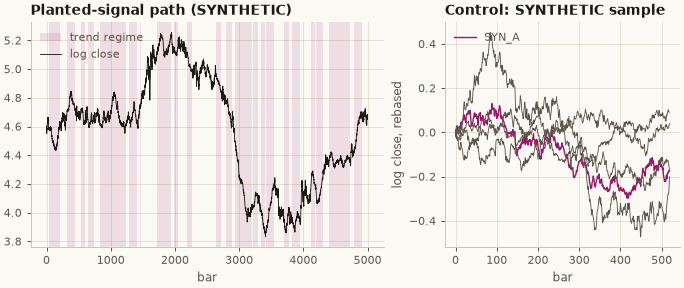

In [4]:
def draw(fig, c):
    left, right = fig.subplots(1, 2, width_ratios=[3, 2])
    x = np.arange(N_BARS)
    logp = np.log(close_h)
    edges = np.flatnonzero(np.diff(np.r_[0, regime_h.astype(int), 0]))  # trend spells [start, end)
    for j, (a, b) in enumerate(zip(edges[::2], edges[1::2])):
        left.axvspan(
            a,
            b,
            color=c["accent"],
            alpha=0.12,
            linewidth=0,
            label="trend regime" if j == 0 else None,
        )
    left.plot(x, logp, color=c["text"], linewidth=0.7, label="log close")
    left.set_title("Planted-signal path (SYNTHETIC)")
    left.set_xlabel("bar")
    left.legend(loc="upper left")
    for i, sym in enumerate(SYMBOLS):
        lc = np.log(control[sym][1])
        right.plot(
            lc - lc[0],
            color=c["accent"] if i == 0 else c["muted"],
            linewidth=1.1 if i == 0 else 0.7,
            label=sym if i == 0 else None,
        )
    right.set_title(f"Control: {LABEL} sample")
    right.set_ylabel("log close, rebased")
    right.set_xlabel("bar")
    right.legend(loc="upper left")


nbfigures.figure(
    "nb11-inputs",
    draw,
    size=(7.6, 3.2),
    alt="Left: log close of the simulated planted-signal path over 5,000 bars, with the hidden trend regime shaded. Right: rebased log closes of the five synthetic sample symbols used as the no-signal control.",
)

## Method

Per series, in this order (all indices are bars; bar $t$'s close is known at the end of bar $t$):

1. **Daily volatility** $\sigma_t$: `volatility.get_daily_vol(span=50)`, AFML Snippet 3.1 (EWM
   standard deviation of the return over the previous day; as in the book, on daily bars that is
   a two-bar return except after a weekend). It uses closes up to $t$.
2. **Events**: a symmetric CUSUM filter on log returns (Snippet 2.4) whose threshold at bar $t$ is
   $2\sigma_{t-1}$. `filters.cusum_filter_indices` takes only a scalar threshold in Python (the
   Rust core also accepts one threshold per bar), so the filter is written here in numpy and
   checked against `cusum_filter_indices` with a constant threshold.
3. **Side** from the primary model: $\text{sign}(\overline{\log P}_{10} - \overline{\log P}_{40})$,
   the 10- and 40-bar moving averages of the log close, ending at the event bar.
4. **Triple-barrier meta-labels**: `labeling.add_vertical_barrier(num_days=14)` (Snippet 3.4),
   then `labeling.triple_barrier_events` with the side, `pt = sl = 1.5` times $\sigma_{t_0}$
   (Snippets 3.3, 3.6) and `labeling.get_bins` (Snippet 3.7): label 1 if the side-signed return from
   $t_0$ to the first barrier touch $t_1$ is positive, else 0. Events too close to the end to get a
   vertical barrier are dropped rather than left open-ended.
5. **Features at $t_0$**, from closes up to $t_0$: `vol_ratio` = log of the 20-bar over the
   250-bar EWM volatility; `efficiency` = $|\log P_{t_0} - \log P_{t_0-20}|$ over the sum of
   absolute daily moves in that window; `ma_gap` = |fast MA - slow MA| scaled by volatility.
6. **Sample weights**: average uniqueness over $[t_0, t_1]$,
   `sampling.get_av_uniqueness_from_triple_barrier` (Snippets 4.1-4.2).
7. **Meta-model**: an L2-penalised logistic regression, fitted by Newton's method in numpy
   (scikit-learn is not a dependency, and no dependency was added), weighted by uniqueness, on
   features standardised with the training fold's mean and s.d. only. Out-of-fold probabilities
   come from `cross_validation.purged_kfold_splits(t0, t1, 5, pct_embargo=0.01)` (Snippet 7.3).
   *Walk-forward* (a sensitivity check) uses the same folds but keeps only training events that
   come before the test fold, so no model sees the future.
8. **Bets and sizes**: primary sizes every bet at its side; `binary@τ` keeps the side when
   $p \ge τ$ and sizes the rest 0; `sized` uses `bet_sizing.get_signal` (Snippet 10.1) with the
   probability of the predicted class. Sizes of concurrent bets are averaged with
   `bet_sizing.avg_active_signals` (Snippet 10.2; skipped bets count as size 0), which gives a
   position $w_t$ held from the close of $t$ to the close of $t+1$.
9. **Returns net of costs**: $w_{t-1} r_t - c\,|w_t - w_{t-1}|$ with $c$ = 5 bps per unit of
   one-way turnover, from the first event bar on. Sharpe ratios are per day (as
   `openquant.evaluation` computes them), with $\times\sqrt{252}$ versions for reading.
10. **Evaluation**: `evaluation.meta_label_metrics` (precision, recall, F1 against the primary
    model, which takes every bet); `evaluation.probabilistic_sharpe_ratio`; and
    `evaluation.TrialRegistry`, which records every configuration's returns so that
    `TrialRegistry.deflated_sharpe_ratio` deflates by the true number of trials.

Several series (the control's five symbols) are pooled into one event table in time order before
the CV split, so purging also removes training events that overlap a test event of another symbol.
Their daily returns are averaged across symbols with equal weight.

**What k-fold CV does and does not show.** A purged k-fold prediction for a 2005 event can come
from a model fitted on 2015 events. That is AFML's way of estimating out-of-sample skill, but it
is not a tradable backtest. The walk-forward check answers the tradable question on the last four
folds.

In [5]:
def rolling_mean(x: np.ndarray, w: int) -> np.ndarray:
    c = np.cumsum(np.r_[0.0, x])
    out = np.full(len(x), np.nan)
    out[w - 1 :] = (c[w:] - c[:-w]) / w
    return out


def ewm_mean(x: np.ndarray, span: int) -> np.ndarray:
    a, out, m = 2.0 / (span + 1.0), np.empty(len(x)), x[0]
    for i, v in enumerate(x):
        m = v if i == 0 else a * v + (1.0 - a) * m
        out[i] = m
    return out


def primary_and_features(close: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Side of the crossover and the meta features at every bar, from closes up to that bar."""
    logp = np.log(close)
    r = np.r_[0.0, np.diff(logp)]
    ma_fast, ma_slow = rolling_mean(logp, FAST), rolling_mean(logp, SLOW)
    side = np.sign(ma_fast - ma_slow)
    vol20, vol250 = np.sqrt(ewm_mean(r**2, 20)), np.sqrt(ewm_mean(r**2, 250))
    with np.errstate(divide="ignore", invalid="ignore"):
        efficiency = np.full(len(close), np.nan)
        efficiency[20:] = np.abs(logp[20:] - logp[:-20]) / (rolling_mean(np.abs(r), 20)[20:] * 20)
        feats = np.column_stack(
            [
                np.log(vol20 / vol250),
                efficiency,
                np.abs(ma_fast - ma_slow) / (vol20 * math.sqrt(SLOW)),
            ]
        )
    feats[: SLOW + 20] = np.nan  # warm-up
    return side, feats


def cusum_events(close: np.ndarray, threshold: np.ndarray) -> np.ndarray:
    """Symmetric CUSUM on log returns with one threshold per bar (Snippet 2.4)."""
    lr = np.diff(np.log(close)).tolist()
    th = threshold.tolist()
    s_pos = s_neg = 0.0
    out = []
    for i in range(1, len(close)):
        if not math.isfinite(th[i]):
            continue
        s_pos, s_neg = max(0.0, s_pos + lr[i - 1]), min(0.0, s_neg + lr[i - 1])
        if s_neg < -th[i]:
            s_neg = 0.0
            out.append(i)
        elif s_pos > th[i]:
            s_pos = 0.0
            out.append(i)
    return np.asarray(out, dtype=np.int64)


def daily_vol(ts: list[str], close: np.ndarray) -> np.ndarray:
    got = dict(volatility.get_daily_vol(ts, close.tolist(), VOL_SPAN))
    return np.array([got.get(t, np.nan) for t in ts])


def build_events(series: dict, cusum_mult: float = CUSUM_MULT) -> dict:
    """Events of every series, pooled in time order: spans, sides, meta-labels, features, weights."""
    parts = []
    for sym, (ts, close) in series.items():
        sigma = daily_vol(ts, close)
        side, feats = primary_and_features(close)
        idx = cusum_events(close, cusum_mult * np.r_[np.nan, sigma[:-1]])
        idx = idx[np.isfinite(sigma[idx]) & np.isfinite(feats[idx]).all(axis=1) & (side[idx] != 0)]
        t_events = [ts[i] for i in idx]
        vertical = labeling.add_vertical_barrier(
            t_events, ts, close.tolist(), num_days=HORIZON_DAYS
        )
        at = {t: i for i, t in enumerate(ts)}
        found = labeling.triple_barrier_events(
            ts,
            close.tolist(),
            [t for t, _ in vertical],
            ts,
            sigma.tolist(),
            pt=PT_SL,
            sl=PT_SL,
            min_ret=0.0,
            vertical_barrier_times=vertical,
            side_prediction=[(t, float(side[at[t]])) for t, _ in vertical],
        )
        bins = labeling.get_bins(found, ts, close.tolist())
        assert [e[0] for e in found] == [b[0] for b in bins]
        t0 = np.array([at[e[0]] for e in found], dtype=np.int64)
        t1 = np.array([at[e[1]] for e in found], dtype=np.int64)
        spans = list(zip(t0.tolist(), t1.tolist()))
        parts.append(
            {
                "symbol": np.full(len(t0), sym),
                "t0": t0,
                "t1": t1,
                "t0_time": np.array([ts[i] for i in t0], dtype="datetime64[ns]"),
                "t1_time": np.array([ts[i] for i in t1], dtype="datetime64[ns]"),
                "side": side[t0],
                "y": np.array([b[3] for b in bins], dtype=np.int64),
                "ret": np.array([b[1] for b in bins]),
                "trgt": np.array([b[2] for b in bins]),
                "X": feats[t0],
                "weight": np.array(sampling.get_av_uniqueness_from_triple_barrier(spans, len(ts))),
            }
        )
    ev = {k: np.concatenate([p[k] for p in parts]) for k in parts[0]}
    order = np.lexsort((ev["symbol"], ev["t0_time"]))
    return {k: v[order] for k, v in ev.items()}


def fit_logit(X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
    """Weighted logistic regression with an L2 penalty on the slopes, by Newton's method."""
    Xb = np.column_stack([np.ones(len(X)), X])
    pen = np.r_[0.0, np.full(X.shape[1], L2)]
    w = w / w.mean()
    beta = np.zeros(Xb.shape[1])
    for _ in range(100):
        p = 1.0 / (1.0 + np.exp(-Xb @ beta))
        grad = Xb.T @ (w * (p - y)) + pen * beta
        hess = (Xb * (w * p * (1.0 - p))[:, None]).T @ Xb + np.diag(pen)
        step = np.linalg.solve(hess, grad)
        beta -= step
        if np.abs(step).max() < 1e-12:
            break
    return beta


def fit_fold(
    ev: dict, cols: list[int], train: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    X = ev["X"][train][:, cols]
    mu, sd = X.mean(axis=0), X.std(axis=0)
    return fit_logit((X - mu) / sd, ev["y"][train].astype(float), ev["weight"][train]), mu, sd


def predict(model, X: np.ndarray) -> np.ndarray:
    beta, mu, sd = model
    return 1.0 / (1.0 + np.exp(-(beta[0] + ((X - mu) / sd) @ beta[1:])))


FEATURE_SETS = {"all": [0, 1, 2], "vol": [0]}


def oof_probability(ev: dict, features: str = "all", walk_forward: bool = False) -> np.ndarray:
    """Out-of-fold P(profitable) for every event; NaN where walk-forward has no earlier data."""
    cols = FEATURE_SETS[features]
    prob = np.full(len(ev["y"]), np.nan)
    for train, test in purged_kfold_splits(ev["t0_time"], ev["t1_time"], N_SPLITS, PCT_EMBARGO):
        if walk_forward:
            train = train[train < test.min()]
            if len(train) < 50:
                continue
        prob[test] = predict(fit_fold(ev, cols, train), ev["X"][test][:, cols])
    return prob


def bet_sizes(ev: dict, prob: np.ndarray | None, rule: str) -> np.ndarray:
    if rule == "primary":
        return ev["side"].astype(float)
    if rule.startswith("binary@"):
        return ev["side"] * (prob >= float(rule.split("@")[1]))
    if rule == "sized":
        p = np.nan_to_num(prob, nan=0.5)
        size = bet_sizing.get_signal(
            np.maximum(p, 1 - p).tolist(), 2, (p >= 0.5).astype(float).tolist()
        )
        return ev["side"] * np.asarray(size)
    if rule == "oracle":
        return ev["side"] * prob  # prob holds the true regime at t0 (1 = trend)
    raise ValueError(rule)


def strategy_returns(
    series: dict, ev: dict, size: np.ndarray, start: dict | None = None
) -> pl.DataFrame:
    """Daily gross and net returns, averaged over symbols; `start` maps symbol -> first bar."""
    frames = []
    for sym, (ts, close) in series.items():
        mine = ev["symbol"] == sym
        t0, t1, s = ev["t0"][mine], ev["t1"][mine], size[mine]
        active = bet_sizing.avg_active_signals([ts[i] for i in t0], s.tolist(), [ts[i] for i in t1])
        pos = np.zeros(len(ts))
        at = {t: i for i, t in enumerate(ts)}
        for (t, value), nxt in zip(active, [*active[1:], (None, None)]):
            pos[at[t] : at[nxt[0]] if nxt[0] is not None else len(ts)] = value
        r = np.r_[0.0, close[1:] / close[:-1] - 1.0]
        gross = np.r_[0.0, pos[:-1] * r[1:]]
        cost = COST_BPS * 1e-4 * np.abs(np.diff(np.r_[0.0, pos]))
        first = (start or {}).get(sym, int(ev["t0"][mine].min()))
        frames.append(
            pl.DataFrame(
                {
                    "ts": ts[first:],
                    "gross": gross[first:],
                    "net": (gross - cost)[first:],
                    "turnover": np.abs(np.diff(np.r_[0.0, pos]))[first:],
                }
            )
        )
    return pl.concat(frames).group_by("ts").mean().sort("ts")


def evaluate(ev: dict, size: np.ndarray, rets: pl.DataFrame) -> dict:
    taken = size != 0
    m = evaluation.meta_label_metrics(ev["y"].tolist(), taken.astype(float).tolist())
    if not taken.any():  # flat: no Sharpe ratio; scored as 0 so a path that skips every bet counts
        zero = {
            "sharpe_net": 0.0,
            "sharpe_net_ann": 0.0,
            "sharpe_gross_ann": 0.0,
            "psr": float("nan"),
        }
        return {"bets": 0, "precision": 0.0, "recall": 0.0, "f1": 0.0, **zero, "turnover": 0.0}
    mom = evaluation.return_moments(rets["net"].to_list())
    return {
        "bets": int(taken.sum()),
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "sharpe_net": mom.sharpe,
        "sharpe_net_ann": mom.sharpe * math.sqrt(252),
        "sharpe_gross_ann": evaluation.return_moments(rets["gross"].to_list()).sharpe
        * math.sqrt(252),
        "psr": evaluation.probabilistic_sharpe_ratio(rets["net"].to_list()),
        "turnover": float(rets["turnover"].mean()),
    }


# The numpy CUSUM must match openquant's with a constant threshold.
_c = control[SYMBOLS[0]][1]
for _h in (0.01, 0.02, 0.04):
    assert cusum_events(
        _c, np.full(len(_c), _h)
    ).tolist() == openquant.filters.cusum_filter_indices(_c.tolist(), _h)
print("numpy CUSUM matches filters.cusum_filter_indices at constant thresholds 0.01, 0.02, 0.04")

numpy CUSUM matches filters.cusum_filter_indices at constant thresholds 0.01, 0.02, 0.04


### The trial grid

Every configuration whose returns this notebook computes on the headline path is recorded in an
`evaluation.TrialRegistry` before any deflated Sharpe ratio is read. The grid is the configurations
the prototype runs looked at, plus the sizing variants the method section names:

- CUSUM multiple 1.0 (the first prototype): primary, and the headline meta rule;
- CUSUM multiple 2.0: primary; `binary@0.5`, `binary@0.55` and `sized`, each on all three features
  and on `vol_ratio` alone; and the headline rule evaluated walk-forward.

That is 10 trials. The oracle is not a trial: it needs the hidden regime and cannot be traded.

In [6]:
def trial_grid() -> list[dict]:
    grid = [
        {"cusum_mult": 1.0, "rule": "primary", "features": None, "cv": None},
        {"cusum_mult": 1.0, "rule": "binary@0.5", "features": "all", "cv": "purged-kfold"},
        {"cusum_mult": CUSUM_MULT, "rule": "primary", "features": None, "cv": None},
    ]
    for features in ("all", "vol"):
        for rule in ("binary@0.5", "binary@0.55", "sized"):
            grid.append(
                {"cusum_mult": CUSUM_MULT, "rule": rule, "features": features, "cv": "purged-kfold"}
            )
    grid.append(
        {"cusum_mult": CUSUM_MULT, "rule": "binary@0.5", "features": "all", "cv": "walk-forward"}
    )
    return grid


def run_grid(
    series: dict, data_label: str, registry: evaluation.TrialRegistry
) -> tuple[pl.DataFrame, dict]:
    rows, kept = [], {}
    events = {m: build_events(series, m) for m in sorted({g["cusum_mult"] for g in trial_grid()})}
    for trial, cfg in enumerate(trial_grid()):
        ev = events[cfg["cusum_mult"]]
        prob = None
        if cfg["cv"] is not None:
            prob = oof_probability(ev, cfg["features"], walk_forward=cfg["cv"] == "walk-forward")
        size = bet_sizes(ev, prob, cfg["rule"])
        start = None
        if cfg["cv"] == "walk-forward":  # score only events that have a walk-forward model
            ok = np.isfinite(prob)
            ev = {k: v[ok] for k, v in ev.items()}
            size, prob = size[ok], prob[ok]
            start = {s: int(ev["t0"][ev["symbol"] == s].min()) for s in series}
        rets = strategy_returns(series, ev, size, start)
        kept[tuple(cfg.values())] = (ev, prob, size, rets)
        if not np.any(size):
            # No bet taken: the returns are all zero and have no Sharpe ratio, so the registry
            # cannot record them. The trial still counts, with a Sharpe ratio of 0 (see deflate).
            no_bet.append({"data": data_label, **cfg})
            rows.append(
                {
                    "trial": trial,
                    "headline": cfg == HEADLINE,
                    **{k: str(v) for k, v in cfg.items()},
                    **evaluate(ev, size, rets),
                }
            )
            continue
        registry.record({"data": data_label, **cfg}, rets["net"].to_list())
        rows.append(
            {
                "trial": trial,
                "headline": cfg == HEADLINE,
                **{k: str(v) for k, v in cfg.items()},
                **evaluate(ev, size, rets),
            }
        )
    return pl.DataFrame(rows, infer_schema_length=None), kept


no_bet: list[dict] = []


def trial_sharpes(registry: evaluation.TrialRegistry, data_label: str) -> list[float]:
    """Every trial's daily Sharpe ratio: the registry's, plus 0 for each trial that took no bet."""
    flat = sum(1 for t in no_bet if t["data"] == data_label)
    return [t.sharpe for t in registry.trials] + [0.0] * flat


def deflate(returns: list[float], registry: evaluation.TrialRegistry, data_label: str) -> float:
    return evaluation.deflated_sharpe_ratio(
        returns, trial_sharpes=trial_sharpes(registry, data_label)
    )


PLANTED_LABEL = "planted-headline-path"
registry_planted = evaluation.TrialRegistry(
    Path(_reg_env) if _reg_env else REGISTRY_DIR / "planted.json"
)
grid_planted, kept_planted = run_grid(planted, PLANTED_LABEL, registry_planted)
N_TRIALS_PLANTED = len(trial_sharpes(registry_planted, PLANTED_LABEL))
print(
    f"trials on the planted path: {N_TRIALS_PLANTED} ({registry_planted.n_trials} in the registry, "
    f"{N_TRIALS_PLANTED - registry_planted.n_trials} took no bet)"
)
print(f"registry: {registry_planted.path}", file=sys.stderr)  # machine-specific path

trials on the planted path: 10 (10 in the registry, 0 took no bet)


registry: /var/folders/68/mjmk1nk54jn2v2gbfqqrh8z40000gn/T/oq-nb11-s82bwxh6/planted.json


## Results

### Headline path: every configuration in the registry

Precision, recall and F1 treat each bet as a prediction that the side-signed return to the
first barrier is positive; primary takes every bet, so its recall is 1. Sharpe ratios are daily
returns net of 5 bps per unit turnover, annualised by $\sqrt{252}$; `psr` is the probability that
the true daily Sharpe ratio is above 0.

In [7]:
with pl.Config(tbl_rows=20, float_precision=3, tbl_width_chars=260, tbl_cols=20):
    print(grid_planted.drop("sharpe_net"))

shape: (10, 14)
┌───────┬──────────┬────────────┬─────────────┬──────────┬──────────────┬──────┬───────────┬────────┬───────┬────────────────┬──────────────────┬───────┬──────────┐
│ trial ┆ headline ┆ cusum_mult ┆ rule        ┆ features ┆ cv           ┆ bets ┆ precision ┆ recall ┆ f1    ┆ sharpe_net_ann ┆ sharpe_gross_ann ┆ psr   ┆ turnover │
│ ---   ┆ ---      ┆ ---        ┆ ---         ┆ ---      ┆ ---          ┆ ---  ┆ ---       ┆ ---    ┆ ---   ┆ ---            ┆ ---              ┆ ---   ┆ ---      │
│ i64   ┆ bool     ┆ str        ┆ str         ┆ str      ┆ str          ┆ i64  ┆ f64       ┆ f64    ┆ f64   ┆ f64            ┆ f64              ┆ f64   ┆ f64      │
╞═══════╪══════════╪════════════╪═════════════╪══════════╪══════════════╪══════╪═══════════╪════════╪═══════╪════════════════╪══════════════════╪═══════╪══════════╡
│ 0     ┆ false    ┆ 1.0        ┆ primary     ┆ None     ┆ None         ┆ 1584 ┆ 0.567     ┆ 1.000  ┆ 0.724 ┆ 0.472          ┆ 0.510            ┆ 0.981 ┆ 0.050

### Headline path: meta against primary and the oracle, and the deflated Sharpe ratio

In [8]:
ev_h, prob_h, size_h, rets_h = kept_planted[tuple(HEADLINE.values())]
_, _, size_p, rets_p = kept_planted[(CUSUM_MULT, "primary", None, None)]
oracle_size = bet_sizes(ev_h, regime_h[ev_h["t0"]].astype(float), "oracle")
rets_o = strategy_returns(planted, ev_h, oracle_size)

headline = pl.DataFrame(
    [
        {"strategy": "primary (crossover, every bet)", **evaluate(ev_h, size_p, rets_p)},
        {"strategy": "primary + meta (headline)", **evaluate(ev_h, size_h, rets_h)},
        {"strategy": "oracle filter (not tradable)", **evaluate(ev_h, oracle_size, rets_o)},
    ]
)
dsr = {
    "primary": deflate(rets_p["net"].to_list(), registry_planted, PLANTED_LABEL),
    "meta": deflate(rets_h["net"].to_list(), registry_planted, PLANTED_LABEL),
}
sr_all = trial_sharpes(registry_planted, PLANTED_LABEL)
sr0 = evaluation.expected_max_sharpe(len(sr_all), float(np.std(sr_all)))
print(
    f"events: {len(ev_h['y'])} | mean uniqueness {ev_h['weight'].mean():.3f} | "
    f"trend-regime events {regime_h[ev_h['t0']].mean():.3f}"
)
with pl.Config(tbl_rows=10, float_precision=3, tbl_width_chars=260, tbl_cols=20):
    print(headline.drop("sharpe_net"))
print(
    f"trials: {len(sr_all)}; s.d. of their daily Sharpe ratios {np.std(sr_all):.4f}; "
    f"expected max daily Sharpe under no skill SR0 = {sr0:.4f} ({sr0 * math.sqrt(252):.2f} annualised)"
)
print(f"deflated Sharpe ratio: primary {dsr['primary']:.3f}, meta {dsr['meta']:.3f}")
print("H4 (meta DSR >= 0.95):", "supported" if dsr["meta"] >= 0.95 else "rejected")

# Post hoc: the configuration a researcher would pick after seeing the grid is the one with the
# highest Sharpe ratio. The DSR exists for exactly that choice, so report it too.
best = grid_planted.sort("sharpe_net", descending=True).row(0, named=True)
best_rets = list(kept_planted.values())[best["trial"]][3]
dsr["best"] = deflate(best_rets["net"].to_list(), registry_planted, PLANTED_LABEL)
print(
    f"best of the grid by Sharpe (post hoc): rule={best['rule']}, features={best['features']}, "
    f"cv={best['cv']}, net Sharpe (ann.) {best['sharpe_net_ann']:.2f}, DSR {dsr['best']:.3f}"
)

events: 708 | mean uniqueness 0.861 | trend-regime events 0.521
shape: (3, 9)
┌────────────────────────────────┬──────┬───────────┬────────┬───────┬────────────────┬──────────────────┬───────┬──────────┐
│ strategy                       ┆ bets ┆ precision ┆ recall ┆ f1    ┆ sharpe_net_ann ┆ sharpe_gross_ann ┆ psr   ┆ turnover │
│ ---                            ┆ ---  ┆ ---       ┆ ---    ┆ ---   ┆ ---            ┆ ---              ┆ ---   ┆ ---      │
│ str                            ┆ i64  ┆ f64       ┆ f64    ┆ f64   ┆ f64            ┆ f64              ┆ f64   ┆ f64      │
╞════════════════════════════════╪══════╪═══════════╪════════╪═══════╪════════════════╪══════════════════╪═══════╪══════════╡
│ primary (crossover, every bet) ┆ 708  ┆ 0.572     ┆ 1.000  ┆ 0.728 ┆ 0.350          ┆ 0.482            ┆ 0.939 ┆ 0.153    │
│ primary + meta (headline)      ┆ 512  ┆ 0.609     ┆ 0.770  ┆ 0.680 ┆ 0.741          ┆ 0.885            ┆ 0.999 ┆ 0.123    │
│ oracle filter (not tradable)   ┆ 369  

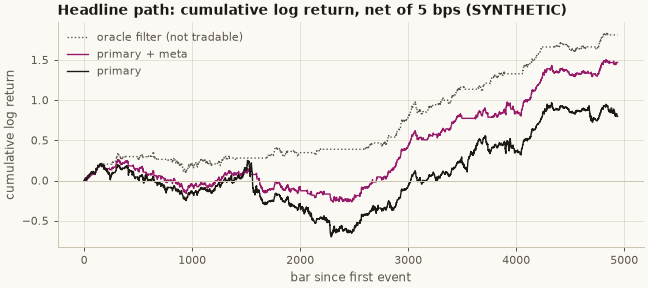

In [9]:
def draw(fig, c):
    ax = fig.subplots()
    for rets, name, col, ls in [
        (rets_o, "oracle filter (not tradable)", c["muted"], ":"),
        (rets_h, "primary + meta", c["accent"], "-"),
        (rets_p, "primary", c["text"], "-"),
    ]:
        x = np.arange(rets.height)
        ax.plot(
            x,
            np.cumsum(np.log1p(rets["net"].to_numpy())),
            color=col,
            linestyle=ls,
            linewidth=1.1,
            label=name,
        )
    ax.axhline(0.0, color=c["rule"], linewidth=0.8)
    ax.set_title("Headline path: cumulative log return, net of 5 bps (SYNTHETIC)")
    ax.set_xlabel("bar since first event")
    ax.set_ylabel("cumulative log return")
    ax.legend(loc="upper left")


nbfigures.figure(
    "nb11-headline-equity",
    draw,
    alt="Cumulative net log return on the planted-signal path for the primary crossover, the crossover filtered by the meta-model, and the oracle filter that knows the regime.",
)

### Monte Carlo: 30 paths per signal strength

The headline configuration, the primary model and the oracle on fresh paths (seeds
`[47, strength index, path]`), for $\kappa_{\text{trend}} \in \{0, 0.12, 0.25\}$ with
$\kappa_{\text{chop}} = -0.4\,\kappa_{\text{trend}}$. $\kappa = 0$ is the zero-signal control. These
paths describe the method and select nothing, so they are not trials. Each row of the second table
is a paired comparison over the paths (meta, walk-forward meta, `sized` or oracle, minus primary):
mean difference and its $t$-statistic.

The `sized` rows were added after the headline grid showed `sized` with the highest Sharpe ratio
on the headline path. They are exploratory, not part of H1-H4. The last table is a diagnostic
for the controls: within each path, the correlation between a test fold's own win rate and the
share of its bets the meta-model takes.

In [10]:
def one_path(k: int, rep: int) -> dict:
    kappa = STRENGTHS[k]
    close, regime = simulate([SEED, k + 1, rep], kappa, -0.4 * kappa)
    series = {"PLANTED": (TS, close)}
    ev = build_events(series)
    prob = oof_probability(ev)
    out = {"kappa": kappa, "rep": rep, "events": len(ev["y"])}
    sizes = {
        "primary": bet_sizes(ev, None, "primary"),
        "meta": bet_sizes(ev, prob, "binary@0.5"),
        "sized": bet_sizes(
            ev, prob, "sized"
        ),  # exploratory, added after the headline grid (see Analysis)
        "oracle": bet_sizes(ev, regime[ev["t0"]].astype(float), "oracle"),
    }
    for name, size in sizes.items():
        res = evaluate(ev, size, strategy_returns(series, ev, size))
        out |= {f"{name}_{m}": res[m] for m in ("precision", "recall", "f1", "sharpe_net_ann")}
    wf = oof_probability(ev, walk_forward=True)
    ok = np.isfinite(wf)
    out["wf_meta_precision"] = float(ev["y"][ok & (wf >= THRESHOLD)].mean())
    out["wf_primary_precision"] = float(ev["y"][ok].mean())
    # Does a fold's share of bets taken track the fold's own base rate (which no model may see)?
    folds = [
        te for _, te in purged_kfold_splits(ev["t0_time"], ev["t1_time"], N_SPLITS, PCT_EMBARGO)
    ]
    rate = [ev["y"][te].mean() for te in folds]
    out["kfold_take_vs_rate"] = float(
        np.corrcoef(rate, [(prob[te] >= THRESHOLD).mean() for te in folds])[0, 1]
    )
    wf_folds = [te for te in folds if np.isfinite(wf[te]).all()]
    out["wf_take_vs_rate"] = float(
        np.corrcoef(
            [ev["y"][te].mean() for te in wf_folds],
            [(wf[te] >= THRESHOLD).mean() for te in wf_folds],
        )[0, 1]
    )
    return out


mc = pl.DataFrame([one_path(k, rep) for k in range(len(STRENGTHS)) for rep in range(N_REPS)])


def paired(a: str, b: str) -> pl.DataFrame:
    rows = []
    for kappa in STRENGTHS:
        g = mc.filter(pl.col("kappa") == kappa)
        d = (g[a] - g[b]).to_numpy()
        rows.append(
            {
                "kappa": kappa,
                "mean_diff": float(d.mean()),
                "t": float(d.mean() / (d.std(ddof=1) / math.sqrt(len(d)))),
                "share_of_paths_up": float((d > 0).mean()),
            }
        )
    return pl.DataFrame(rows)


tests = pl.concat(
    [
        paired("meta_precision", "primary_precision").with_columns(
            pl.lit("H1 precision").alias("test")
        ),
        paired("meta_f1", "primary_f1").with_columns(pl.lit("H2 F1").alias("test")),
        paired("meta_sharpe_net_ann", "primary_sharpe_net_ann").with_columns(
            pl.lit("H3 Sharpe (ann.)").alias("test")
        ),
        paired("wf_meta_precision", "wf_primary_precision").with_columns(
            pl.lit("precision, walk-forward").alias("test")
        ),
        paired("sized_sharpe_net_ann", "primary_sharpe_net_ann").with_columns(
            pl.lit("post hoc: sized Sharpe (ann.)").alias("test")
        ),
        paired("oracle_precision", "primary_precision").with_columns(
            pl.lit("oracle precision").alias("test")
        ),
        paired("oracle_sharpe_net_ann", "primary_sharpe_net_ann").with_columns(
            pl.lit("oracle Sharpe (ann.)").alias("test")
        ),
    ]
).select("test", "kappa", "mean_diff", "t", "share_of_paths_up")
means = mc.group_by("kappa").mean().sort("kappa").drop("rep")
with pl.Config(tbl_rows=30, float_precision=3, tbl_width_chars=260, tbl_cols=30):
    print(
        means.select(
            "kappa",
            "events",
            "primary_precision",
            "meta_precision",
            "oracle_precision",
            "meta_recall",
            "primary_f1",
            "meta_f1",
            "primary_sharpe_net_ann",
            "meta_sharpe_net_ann",
            "sized_sharpe_net_ann",
            "oracle_sharpe_net_ann",
        )
    )
    print(tests)
    print("mean over paths of corr(test fold's base rate, share of its bets taken):")
    print(
        mc.group_by("kappa")
        .agg(
            pl.col("kfold_take_vs_rate").fill_nan(None).mean(),
            pl.col("wf_take_vs_rate").fill_nan(None).mean(),
        )
        .sort("kappa")
    )

shape: (3, 12)
┌───────┬─────────┬───────────────────┬────────────────┬──────────────────┬─────────────┬────────────┬─────────┬────────────────────────┬─────────────────────┬──────────────────────┬───────────────────────┐
│ kappa ┆ events  ┆ primary_precision ┆ meta_precision ┆ oracle_precision ┆ meta_recall ┆ primary_f1 ┆ meta_f1 ┆ primary_sharpe_net_ann ┆ meta_sharpe_net_ann ┆ sized_sharpe_net_ann ┆ oracle_sharpe_net_ann │
│ ---   ┆ ---     ┆ ---               ┆ ---            ┆ ---              ┆ ---         ┆ ---        ┆ ---     ┆ ---                    ┆ ---                 ┆ ---                  ┆ ---                   │
│ f64   ┆ f64     ┆ f64               ┆ f64            ┆ f64              ┆ f64         ┆ f64        ┆ f64     ┆ f64                    ┆ f64                 ┆ f64                  ┆ f64                   │
╞═══════╪═════════╪═══════════════════╪════════════════╪══════════════════╪═════════════╪════════════╪═════════╪════════════════════════╪════════════════════

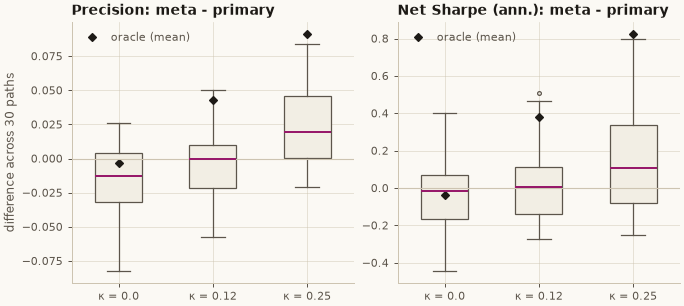

In [11]:
def draw(fig, c):
    left, right = fig.subplots(1, 2)
    for ax, (a, b, title) in zip(
        (left, right),
        [
            ("meta_precision", "primary_precision", "Precision: meta - primary"),
            ("meta_sharpe_net_ann", "primary_sharpe_net_ann", "Net Sharpe (ann.): meta - primary"),
        ],
    ):
        data = [
            (mc.filter(pl.col("kappa") == k)[a] - mc.filter(pl.col("kappa") == k)[b]).to_numpy()
            for k in STRENGTHS
        ]
        oracle = a.replace("meta", "oracle")
        ax.boxplot(
            data,
            positions=range(len(STRENGTHS)),
            widths=0.5,
            patch_artist=True,
            boxprops={"facecolor": c["surface"], "edgecolor": c["muted"]},
            medianprops={"color": c["accent"], "linewidth": 1.6},
            whiskerprops={"color": c["muted"]},
            capprops={"color": c["muted"]},
            flierprops={"markeredgecolor": c["muted"], "markersize": 3},
        )
        orc = [
            float(
                (
                    mc.filter(pl.col("kappa") == k)[oracle] - mc.filter(pl.col("kappa") == k)[b]
                ).mean()
            )
            for k in STRENGTHS
        ]
        ax.plot(
            range(len(STRENGTHS)),
            orc,
            marker="D",
            markersize=5,
            linestyle="none",
            color=c["text"],
            label="oracle (mean)",
        )
        ax.axhline(0.0, color=c["rule"], linewidth=0.9)
        ax.set_xticks(range(len(STRENGTHS)), [f"κ = {k}" for k in STRENGTHS])
        ax.set_title(title)
        ax.legend(loc="upper left")
    left.set_ylabel(f"difference across {N_REPS} paths")


nbfigures.figure(
    "nb11-monte-carlo",
    draw,
    size=(7.6, 3.4),
    alt="Box plots over simulated paths of the precision gain and the net Sharpe ratio gain of the meta-labeled strategy over the primary model, at signal strengths 0, 0.12 and 0.25, with the oracle filter's mean gain marked.",
)

### Control: the SYNTHETIC `fetch` sample

The same grid of 10 configurations on the five `SYN_*` symbols pooled, recorded in a registry of
its own. These are random walks: the right answer is no edge for primary, and nothing for
meta-labeling to find.

In [12]:
registry_control = evaluation.TrialRegistry(
    Path(_reg_env).with_name(Path(_reg_env).stem + "-control.json")
    if _reg_env
    else REGISTRY_DIR / "control.json"
)
CONTROL_LABEL = f"control-{meta['dataset_hash'][7:19]}"
grid_control, kept_control = run_grid(control, CONTROL_LABEL, registry_control)
ev_c, prob_c, size_c, rets_c = kept_control[tuple(HEADLINE.values())]
_, _, size_cp, rets_cp = kept_control[(CUSUM_MULT, "primary", None, None)]
dsr_control = {
    "primary": deflate(rets_cp["net"].to_list(), registry_control, CONTROL_LABEL),
    "meta": deflate(rets_c["net"].to_list(), registry_control, CONTROL_LABEL)
    if np.any(size_c)
    else float("nan"),
}
n_control = len(trial_sharpes(registry_control, CONTROL_LABEL))
print(
    f"{LABEL} control: {len(ev_c['y'])} events over {len(SYMBOLS)} symbols; trials {n_control} "
    f"({registry_control.n_trials} in the registry, {n_control - registry_control.n_trials} took no bet)"
)
with pl.Config(tbl_rows=20, float_precision=3, tbl_width_chars=260, tbl_cols=20):
    print(grid_control.drop("sharpe_net"))
print(
    f"deflated Sharpe ratio: primary {dsr_control['primary']:.3f}, meta {dsr_control['meta']:.3f}"
)

SYNTHETIC control: 316 events over 5 symbols; trials 10 (9 in the registry, 1 took no bet)
shape: (10, 14)
┌───────┬──────────┬────────────┬─────────────┬──────────┬──────────────┬──────┬───────────┬────────┬───────┬────────────────┬──────────────────┬───────┬──────────┐
│ trial ┆ headline ┆ cusum_mult ┆ rule        ┆ features ┆ cv           ┆ bets ┆ precision ┆ recall ┆ f1    ┆ sharpe_net_ann ┆ sharpe_gross_ann ┆ psr   ┆ turnover │
│ ---   ┆ ---      ┆ ---        ┆ ---         ┆ ---      ┆ ---          ┆ ---  ┆ ---       ┆ ---    ┆ ---   ┆ ---            ┆ ---              ┆ ---   ┆ ---      │
│ i64   ┆ bool     ┆ str        ┆ str         ┆ str      ┆ str          ┆ i64  ┆ f64       ┆ f64    ┆ f64   ┆ f64            ┆ f64              ┆ f64   ┆ f64      │
╞═══════╪══════════╪════════════╪═════════════╪══════════╪══════════════╪══════╪═══════════╪════════╪═══════╪════════════════╪══════════════════╪═══════╪══════════╡
│ 0     ┆ false    ┆ 1.0        ┆ primary     ┆ None     ┆ None     

### Look-ahead and leakage checks

1. **Features, sides, volatility and events use only the past.** Replace every close after bar
   $t^*$ with noise: nothing at or before $t^*$ may change.
2. **A label uses only its own span.** For 40 events, replace every close after $t_1$ with noise:
   $t_1$ and the label may not change. Replacing the closes inside $(t_0, t_1]$ must change some
   labels (so the test can fail).
3. **Purging and embargo.** In every fold, no training label overlaps the test fold
   (`count_train_test_overlaps`), and no embargoed event is trained on; unpurged k-fold on the same
   events does overlap.
4. **The meta-model never sees the test fold.** Replace the test fold's features and labels with
   noise: the fitted coefficients must be bit-identical.

In [13]:
rng = np.random.default_rng([SEED, 10**6])
cut = N_BARS // 2
shocked = close_h.copy()
shocked[cut + 1 :] = close_h[cut] * np.exp(np.cumsum(rng.normal(0.0, 0.03, N_BARS - cut - 1)))
side_a, feat_a = primary_and_features(close_h)
side_b, feat_b = primary_and_features(shocked)
vol_a, vol_b = daily_vol(TS, close_h), daily_vol(TS, shocked)
thr_a, thr_b = CUSUM_MULT * np.r_[np.nan, vol_a[:-1]], CUSUM_MULT * np.r_[np.nan, vol_b[:-1]]
ev_a, ev_b = cusum_events(close_h, thr_a), cusum_events(shocked, thr_b)
check1 = {
    "side": np.array_equal(side_a[: cut + 1], side_b[: cut + 1], equal_nan=True),
    "features": np.array_equal(feat_a[: cut + 1], feat_b[: cut + 1], equal_nan=True),
    "daily vol": np.array_equal(vol_a[: cut + 1], vol_b[: cut + 1], equal_nan=True),
    "events": ev_a[ev_a <= cut].tolist() == ev_b[ev_b <= cut].tolist(),
    "the future did change": not np.array_equal(
        feat_a[cut + 1 :], feat_b[cut + 1 :], equal_nan=True
    ),
}
print("1. unchanged up to the cut:", check1)
assert all(check1.values())

sigma_h = daily_vol(TS, close_h)
unchanged, changed_inside = 0, 0
for i in rng.choice(len(ev_h["y"]), 40, replace=False):
    a, b = int(ev_h["t0"][i]), int(ev_h["t1"][i])
    for lo, hi, what in [(b + 1, N_BARS, "after"), (a + 1, b + 1, "inside")]:
        path = close_h.copy()
        path[lo:hi] = close_h[lo - 1] * np.exp(np.cumsum(rng.normal(0.0, 0.03, hi - lo)))
        vb = labeling.add_vertical_barrier([TS[a]], TS, path.tolist(), num_days=HORIZON_DAYS)
        e = labeling.triple_barrier_events(
            TS,
            path.tolist(),
            [TS[a]],
            [TS[a]],
            [float(sigma_h[a])],
            pt=PT_SL,
            sl=PT_SL,
            vertical_barrier_times=vb,
            side_prediction=[(TS[a], float(ev_h["side"][i]))],
        )
        label = labeling.get_bins(e, TS, path.tolist())[0][3]
        same = e[0][1] == TS[b] and label == ev_h["y"][i]
        if what == "after":
            unchanged += same
        else:
            changed_inside += not same
print(
    f"2. labels unchanged when the future after t1 changes: {unchanged} of 40; "
    f"changed when (t0, t1] changes: {changed_inside} of 40"
)
assert unchanged == 40 and changed_inside > 0

folds = split_with_diagnostics(ev_h["t0_time"], ev_h["t1_time"], N_SPLITS, PCT_EMBARGO)
overlaps = [
    count_train_test_overlaps(
        ev_h["t0_time"], ev_h["t1_time"], f["train_indices"], f["test_indices"]
    )
    for f in folds
]
embargo_trained = [len(np.intersect1d(f["embargo_indices"], f["train_indices"])) for f in folds]
naive = [
    count_train_test_overlaps(ev_h["t0_time"], ev_h["t1_time"], tr, te)
    for tr, te in naive_kfold_splits(len(ev_h["y"]), N_SPLITS)
]
print(
    f"3. purged: train/test overlaps per fold {overlaps}, embargoed events trained on {embargo_trained}; "
    f"purged {[len(f['purged_indices']) for f in folds]}, embargoed {[len(f['embargo_indices']) for f in folds]}; "
    f"unpurged k-fold overlaps {naive}"
)
assert sum(overlaps) == 0 and sum(embargo_trained) == 0 and sum(naive) > 0

identical = 0
for train, test in purged_kfold_splits(ev_h["t0_time"], ev_h["t1_time"], N_SPLITS, PCT_EMBARGO):
    noisy = {**ev_h, "X": ev_h["X"].copy(), "y": ev_h["y"].copy()}
    noisy["X"][test] = rng.normal(size=noisy["X"][test].shape)
    noisy["y"][test] = rng.integers(0, 2, len(test))
    a_model, b_model = fit_fold(ev_h, [0, 1, 2], train), fit_fold(noisy, [0, 1, 2], train)
    identical += all(np.array_equal(x, y) for x, y in zip(a_model, b_model))
print(
    f"4. folds whose fitted model is bit-identical after the test fold is replaced with noise: {identical} of {N_SPLITS}"
)
assert identical == N_SPLITS

1. unchanged up to the cut: {'side': True, 'features': True, 'daily vol': True, 'events': True, 'the future did change': True}


2. labels unchanged when the future after t1 changes: 40 of 40; changed when (t0, t1] changes: 40 of 40
3. purged: train/test overlaps per fold [0, 0, 0, 0, 0], embargoed events trained on [0, 0, 0, 0, 0]; purged [0, 0, 1, 2, 1], embargoed [8, 16, 16, 16, 8]; unpurged k-fold overlaps [0, 0, 1, 2, 1]
4. folds whose fitted model is bit-identical after the test fold is replaced with noise: 5 of 5


## Analysis

In [14]:
h = {r["strategy"]: r for r in headline.iter_rows(named=True)}
p, m_, o = (
    h["primary (crossover, every bet)"],
    h["primary + meta (headline)"],
    h["oracle filter (not tradable)"],
)
print(
    f"headline path: precision {p['precision']:.3f} -> {m_['precision']:.3f} (oracle {o['precision']:.3f}); "
    f"F1 {p['f1']:.3f} -> {m_['f1']:.3f}; net Sharpe (ann.) {p['sharpe_net_ann']:.2f} -> "
    f"{m_['sharpe_net_ann']:.2f} (oracle {o['sharpe_net_ann']:.2f}); DSR {dsr['primary']:.3f} -> {dsr['meta']:.3f}"
)
verdict = {}
for test in ("H1 precision", "H2 F1", "H3 Sharpe (ann.)"):
    row = tests.filter((pl.col("test") == test) & (pl.col("kappa") == KAPPA_TREND)).row(
        0, named=True
    )
    null = tests.filter((pl.col("test") == test) & (pl.col("kappa") == 0.0)).row(0, named=True)
    verdict[test] = row["t"] > 1.645
    print(
        f"{test}: kappa={KAPPA_TREND} mean diff {row['mean_diff']:+.4f}, t = {row['t']:.2f} -> "
        f"{'supported' if verdict[test] else 'rejected'}; null kappa=0: t = {null['t']:.2f} "
        f"-> control (|t| < 1.96) {'passes' if abs(null['t']) < 1.96 else 'fails, ' + ('against meta' if null['t'] < 0 else 'FALSE POSITIVE')}"
    )
print(
    f"H4 (headline-path DSR >= 0.95): {'supported' if dsr['meta'] >= 0.95 else 'rejected'} (DSR {dsr['meta']:.3f})"
)
print(
    f"control ({LABEL}): meta DSR {dsr_control['meta']:.3f} -> "
    f"{'FALSE DISCOVERY' if dsr_control['meta'] >= 0.95 else 'passes (no false discovery)'}"
)

headline path: precision 0.572 -> 0.609 (oracle 0.650); F1 0.728 -> 0.680; net Sharpe (ann.) 0.35 -> 0.74 (oracle 1.27); DSR 0.340 -> 0.905
H1 precision: kappa=0.25 mean diff +0.0218, t = 4.21 -> supported; null kappa=0: t = -3.46 -> control (|t| < 1.96) fails, against meta
H2 F1: kappa=0.25 mean diff -0.0840, t = -11.41 -> rejected; null kappa=0: t = -9.56 -> control (|t| < 1.96) fails, against meta
H3 Sharpe (ann.): kappa=0.25 mean diff +0.1365, t = 2.78 -> supported; null kappa=0: t = -0.57 -> control (|t| < 1.96) passes
H4 (headline-path DSR >= 0.95): rejected (DSR 0.905)
control (SYNTHETIC): meta DSR 0.002 -> passes (no false discovery)


The committed numbers come from SYNTHETIC data. They describe the procedure on data whose answer
is known, not a market.

1. **H1 (precision) is supported.** At the headline strength, meta raises precision from 0.543 to
   0.565 on average over 30 paths (+0.022, $t$ = 4.2, higher on 77% of paths). On the headline path
   it goes from 0.572 to 0.609. The oracle reaches 0.634 on average, so meta recovers about a
   quarter of the precision a perfect regime filter would add. Walk-forward, where no model sees
   the future, gives nearly the same gain (+0.018, $t$ = 3.9).
2. **H3 (net Sharpe ratio) is supported across paths, and H4 is rejected on the one path.** Across
   paths, meta's net Sharpe ratio is 0.31 against primary's 0.18 (annualised; +0.14, $t$ = 2.8,
   higher on two paths in three). The oracle's is 1.00, so meta recovers about a sixth of the
   available improvement. On the headline path, meta's 0.74 against primary's 0.35 has a PSR of
   0.999. Deflated by the 10 configurations tried on that path, the DSR is 0.905, below the
   pre-registered 0.95. The trials' Sharpe ratios are spread widely (s.d. 0.28 annualised), so
   luck alone would be expected to reach 0.44. Nineteen years of one path cannot separate a
   filter this weak from a lucky choice among ten.
3. **H2 (F1) is rejected, at every strength, and has to be.** Primary takes every bet, so its
   recall is 1 by construction and its F1 is $2b/(1+b)$ at base rate $b$ (0.70 here). Meta gives
   up 30% of recall to gain 2 points of precision, so its F1 falls (0.620 against 0.704;
   $t = -11$). F1 rewards meta-labeling only when the primary model's precision is low compared
   with what the filter can reach. Here it is not, so precision and the deflated Sharpe ratio are
   the measures that answer the question. §3.6's F1 argument does not transfer to a primary model
   that is already right more often than not.
4. **A weaker signal is invisible to meta-labeling.** At $\kappa_{\text{trend}} = 0.12$ the oracle
   still gains 4.3 precision points on every path and 0.38 of Sharpe ratio on average, but meta gains nothing
   ($t$ = -0.4 for precision, 0.6 for Sharpe). With about 550 training events per fold and
   features that only proxy the regime, the meta-model needs a large conditional edge before it
   can learn it. The calibration history (see Data) says the same.
5. **Controls.** On the `SYN_*` sample the crossover has no edge: precision 0.449, net Sharpe
   ratio -0.60. The meta-model rejects 91% of its bets, and its DSR is 0.002. It invents nothing.
   On the zero-signal generator, meta's Sharpe ratio is no different from primary's ($t$ = -0.6).
   The pre-registered two-sided control fails for precision, in the direction *against* meta:
   -0.014, $t$ = -3.5. It also fails for F1, for the reason in point 3. The precision bias is not
   a leak, because check 4 shows no model can see its test fold. It comes from how the comparison
   is made:
   - **k-fold.** A test fold with an unusually high win rate leaves a training set with a low
     one. The model's intercept follows the training base rate, so it takes fewer of that fold's
     bets. Within a path, the correlation between a fold's win rate and the share of its bets taken
     is -0.78 at $\kappa = 0$.
   - **Walk-forward.** Walk-forward shows -0.39. Deviations from a path's own average sum to zero,
     so a fold that follows high-rate folds tends to fall below that average.

   Both effects fade as the signal grows (-0.16 and 0.02 at $\kappa = 0.25$). So a per-path
   precision comparison of a cross-validated meta-model is biased *against* it when there is
   nothing to find. H1's support is conservative, and a precision gain should be read against a
   null run like this one, not against zero.
6. **Post hoc: probability sizing.** The best configuration on the headline path is `sized`
   (Snippet 10.1 on the meta probability): net Sharpe ratio 1.27, DSR 1.000 after deflating for all
   10 trials. In the Monte Carlo, added after that was seen, `sized` gains 0.35 of Sharpe ratio
   over primary at $\kappa = 0.25$ ($t$ = 6.0), about twice the binary filter's gain. Under the
   null it *loses* 0.08 ($t$ = -2.5), because it amplifies the same bias. It was not
   pre-registered, so it is a candidate for the next runbook, not a result of this one.
7. **No look-ahead.** All four checks pass: features, sides, volatility and events ignore the
   future; labels ignore everything after their own $t_1$; purging and the embargo leave no
   overlap; and the fitted models are bit-identical when the test fold is replaced with noise.
8. **Library gaps met on the way (not fixed here).**
   - `filters.cusum_filter_*` takes only a scalar threshold from Python, although the Rust
     core accepts one per bar.
   - `sb_bagging.fit_predict_sb_classifier` returns predictions for its own training rows only, so
     it cannot produce out-of-fold probabilities. Sequential-bootstrap bagging is therefore not in
     this study.
   - `evaluation.TrialRegistry.record` rejects a configuration whose returns are constant, such
     as a filter that takes no bet. The control's one such trial is counted here with a Sharpe
     ratio of 0.

## Promotion decision

**Decision: promote the procedure, not a strategy and not the F1 claim.**

Promoted as the default meta-labeling stage for later runbooks that have a primary model:
- triple-barrier meta-labels from the primary model's side;
- uniqueness-weighted meta-model fitted on training folds only;
- out-of-fold probabilities from purged k-fold, with a walk-forward check;
- every configuration recorded in a `TrialRegistry`, and the deflated Sharpe ratio read from it.

On data with a known, weak, time-varying edge, this procedure finds part of the edge. It raises
precision and the net Sharpe ratio across paths, and it stays below the oracle. On data with no
edge it finds nothing: no false discovery on the `SYN_*` sample, and no Sharpe gain at
$\kappa = 0$.

Not promoted:
- **Any strategy.** The pre-registered strategy's DSR on the headline path is 0.905, below 0.95.
  Everything here is synthetic.
- **"Meta-labeling improves F1."** It cannot when the primary model takes every bet and is
  already right more often than not.
- **Binary filtering at 0.5 as the sizing rule.** Probability sizing did better, post hoc. It
  should be the pre-registered rule next time, with its own trial count.

Conditions for later runbooks that use this stage:
- Judge it on precision and the deflated Sharpe ratio, not F1.
- Run a null (zero-signal simulation, or labels permuted within folds) through the same CV, and
  compare the precision gain against that null. The per-path comparison is biased against
  meta-labeling when there is no signal.
- Persist the trial registry (`OPENQUANT_RUNBOOK_REGISTRY`) across sessions, so the deflation
  counts every configuration ever tried on that data.

This decision describes the procedure on synthetic series. It says nothing about any real
instrument. Run the notebook on your own data (see the top cell) and read the control tables
next to your own.

## Self-review checklist

- [x] **No look-ahead in features, sides, volatility or events.** Check 1 replaces every close
  after the cut and nothing at or before it changes. The CUSUM threshold at bar $t$ uses the
  volatility known at $t-1$; the barrier width uses the volatility at $t_0$.
- [x] **Labels use only the future inside their own span.** Check 2: a label and its $t_1$ do not
  change when closes after $t_1$ change, and do when closes inside $(t_0, t_1]$ change. Events
  without a vertical barrier (the last 14 days) are dropped, not left open-ended.
- [x] **Purge and embargo honoured.** Check 3: zero train/test label overlaps in every fold, and no
  embargoed event is trained on. Check 4: a fold's fitted model, including its feature
  standardisation, is bit-identical when the test fold's features and labels are replaced with
  noise.
- [x] **k-fold is not a backtest.** This is stated in Method. A walk-forward version is in the
  registry and the Monte Carlo, and gives the same precision gain.
- [x] **Trial count complete.**
  - **Headline path: 10 configurations**, all in the `TrialRegistry`, and the DSR deflates by all
    10: the two CUSUM multiples tried in the prototypes, the primary model, three rules × two
    feature sets, and walk-forward.
  - **Control: 10 configurations.** One took no bet; the registry cannot store it, so it is counted
    with a Sharpe ratio of 0.
  - **Fixed before the first run:** the pipeline parameters (barriers, horizon, MA windows, folds,
    embargo, L2, threshold, cost).
  - **Calibrated before this notebook existed:** the generator's strength, disclosed with every
    setting tried (Data).
  - **Not trials:** the Monte Carlo paths, which describe the method and select nothing. The
    `sized` Monte Carlo rows were added after seeing the grid and are labelled post hoc.
- [x] **Costs included.** 5 bps per unit of one-way turnover on every strategy, with gross and net
  Sharpe ratios in the grid.
- [x] **Seeds fixed.** The headline path is `[47, 0]`, Monte Carlo paths are `[47, k + 1, path]`,
  and the check noise is `[47, 10**6]`.
- [x] **Everything is labelled SYNTHETIC**, including the tables, printouts and figure titles.
- [ ] **Not covered: sequential-bootstrap bagging** (issue #47's scope). `sb_bagging` cannot
  predict out of sample from Python (Analysis, point 8). The meta-model is a single uniqueness-
  weighted logistic regression instead.

## Reproducibility

In [15]:
def git_sha() -> str:
    try:
        return subprocess.run(
            ["git", "rev-parse", "HEAD"], capture_output=True, text=True, check=True
        ).stdout.strip()
    except (OSError, subprocess.CalledProcessError):
        return "unknown"


manifest = openquant.research.research_run_manifest(
    {
        "notebook": "11_meta_labeling_triple_barrier",
        "seed": SEED,
        "generator": {
            "n_bars": N_BARS,
            "p_stay": P_STAY,
            "vol": [VOL_TREND, VOL_CHOP],
            "logvol": [LOGVOL_AR, LOGVOL_SD],
            "mom_len": MOM_LEN,
            "kappa": [KAPPA_TREND, KAPPA_CHOP],
            "strengths": list(STRENGTHS),
            "reps": N_REPS,
        },
        "pipeline": {
            "vol_span": VOL_SPAN,
            "cusum_mult": CUSUM_MULT,
            "pt_sl": PT_SL,
            "horizon_days": HORIZON_DAYS,
            "ma": [FAST, SLOW],
            "n_splits": N_SPLITS,
            "pct_embargo": PCT_EMBARGO,
            "l2": L2,
            "threshold": THRESHOLD,
            "cost_bps": COST_BPS,
            "features": list(FEATURES),
        },
        "headline": HEADLINE,
        "symbols": SYMBOLS,
        "trials": {
            "planted": N_TRIALS_PLANTED,
            "control": n_control,
            "monte_carlo_paths": mc.height,
        },
    }
)
openquant.data.record_dataset_hash(
    manifest,
    digest=meta["dataset_hash"],
    **{k: meta[k] for k in ("source", "symbols", "start", "end", "rows")},
)
manifest["planted_hash"] = planted_hash

print("package:      pyopenquant", version("pyopenquant"))
print("numpy:       ", np.__version__, "| polars:", pl.__version__)
print("data hash:   ", manifest["dataset_hash"], f"({LABEL} control)")
print("planted:     ", planted_hash, file=sys.stderr)  # platform-dependent float bits, see Data
print("seed:        ", SEED)
print("trials:      ", manifest["config"]["trials"])
print("config:      ", manifest["config_digest"])
# The commit changes with every commit, so it goes to stderr, which the staleness check ignores.
print("git sha:     ", git_sha(), file=sys.stderr)

package:      pyopenquant 0.1.0
numpy:        2.4.6 | polars: 1.38.1
data hash:    sha256:b311c219efb2a19db449767cc8600139c030aad15496b011fc650b4880550eea (SYNTHETIC control)
seed:         47
trials:       {'planted': 10, 'control': 10, 'monte_carlo_paths': 90}
config:       9d282f36c296


planted:      sha256:848abe52ec77aabf3c66917e0964a2bcd2718f4f30ea6ecee621c3cc2ed5b599
git sha:      1f291db080a36218ed9d4e42191f585f54f4445f
